#Step1.Upload Dataset

In [ ]:
# Import the files module from google.colab to handle file uploads
from google.colab import files

# Upload files from your local system to the Colab environment
uploaded = files.upload()

Saving dataset.csv to dataset.csv


In [ ]:
# Import the pandas library for data manipulation
import pandas as pd

# Read the uploaded CSV file into a pandas DataFrame
df = pd.read_csv('dataset.csv')

# Display the first 5 rows of the DataFrame to get a preview of the data
df.head()

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


#Step2: Import Required Libraries

In [ ]:
# Import numpy for numerical operations
import numpy as np
# Import pandas for data manipulation (already imported, but good practice for self-contained cells)
import pandas as pd
# Import matplotlib.pyplot for plotting
import matplotlib.pyplot as plt
# Import seaborn for advanced data visualization
import seaborn as sns

# Import train_test_split for splitting data into training and testing sets
from sklearn.model_selection import train_test_split
# Import StandardScaler for feature scaling
from sklearn.preprocessing import StandardScaler
# Import evaluation metrics: Mean Absolute Error, Mean Squared Error, R-squared score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import RandomForestRegressor for building the regression model
from sklearn.ensemble import RandomForestRegressor

#Step3: Understand Dataset

In [ ]:
# Check dataset info to understand data types, non-null values, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72946 entries, 0 to 72945
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   72946 non-null  int64  
 1   open         72946 non-null  float64
 2   high         72946 non-null  float64
 3   low          72946 non-null  float64
 4   close        72946 non-null  float64
 5   volume       72946 non-null  float64
 6   marketCap    72946 non-null  float64
 7   timestamp    72946 non-null  object 
 8   crypto_name  72946 non-null  object 
 9   date         72946 non-null  object 
dtypes: float64(6), int64(1), object(3)
memory usage: 5.6+ MB


In [ ]:
# Check for null (missing) values in each column and sum them up
df.isnull().sum()

,0
Unnamed: 0,0
open,0
high,0
low,0
close,0
volume,0
marketCap,0
timestamp,0
crypto_name,0
date,0


In [ ]:
# Generate descriptive statistics of the DataFrame to understand data distribution
df.describe()

,Unnamed: 0,open,high,low,close,volume,marketCap
count,72946.000000,72946.000000,7.294600e+04,72946.000000,7.294600e+04,7.294600e+04,7.294600e+04
mean,36472.500000,870.194495,8.964124e+02,844.060640,8.712949e+02,2.207607e+09,1.474922e+10
std,21057.840705,5231.654470,5.398613e+03,5079.389387,5.235508e+03,9.617885e+09,7.501159e+10
min,0.000000,0.000000,1.022100e-10,0.000000,8.292000e-11,0.000000e+00,0.000000e+00
25%,18236.250000,0.167916,1.767999e-01,0.158630,1.682982e-01,8.320618e+06,1.860432e+08
50%,36472.500000,1.630666,1.717542e+00,1.541486,1.640219e+00,1.098756e+08,1.268539e+09
75%,54708.750000,26.070557,2.756868e+01,24.791776,2.625195e+01,6.691398e+08,5.118618e+09
max,72945.000000,67549.735581,1.621883e+05,66458.723733,6.756683e+04,3.509679e+11,1.274831e+12


#Step4: Data Cleaning

In [ ]:
# Remove the 'Unnamed: 0' column as it appears to be an artifact from CSV export and is not needed
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
# Convert the 'date' column to datetime objects for proper time-series analysis
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# Sort the DataFrame by the 'date' column to ensure chronological order
df = df.sort_values('date')

#Step5: Create Volatility Feature



In [ ]:
# Calculate 'volatility' as (High - Low) / Open. This measures the price range relative to the opening price.
df['volatility'] = (df['high'] - df['low']) / df['open']

In [ ]:
# Display the 'open', 'high', 'low', and 'volatility' columns for the first few rows
# This helps in verifying the newly created 'volatility' feature
df[['open', 'high', 'low', 'volatility']].head()

,open,high,low,volatility
0,112.900002,118.800003,107.142998,0.103251
1,3.493130,3.692460,3.346060,0.099166
2,115.980003,124.663002,106.639999,0.155398
3,3.594220,3.781020,3.116020,0.185019
4,112.250000,113.444000,97.699997,0.140258


#Step6: Feature Engineering

In [ ]:
# Calculate 7-day Moving Average (MA_7) of the 'close' price
df['MA_7'] = df['close'].rolling(window=7).mean()
# Calculate 30-day Moving Average (MA_30) of the 'close' price
df['MA_30'] = df['close'].rolling(window=30).mean()

In [ ]:
# Calculate the 7-day rolling standard deviation of the 'close' price
# This helps in understanding the price variability over a 7-day period
df['Rolling_STD'] = df['close'].rolling(window=7).std()

In [ ]:
# Calculate 'Liquidity' as Volume / MarketCap
# This feature can indicate how easily an asset can be bought or sold without affecting its price
df['Liquidity'] = df['volume'] / df['marketCap']

In [ ]:
# Remove any rows that contain NaN (Not a Number) values
# NaN values can arise from rolling window calculations at the start of the series
df = df.dropna()

#Step 7: Exploratory Data Analysis (EDA)

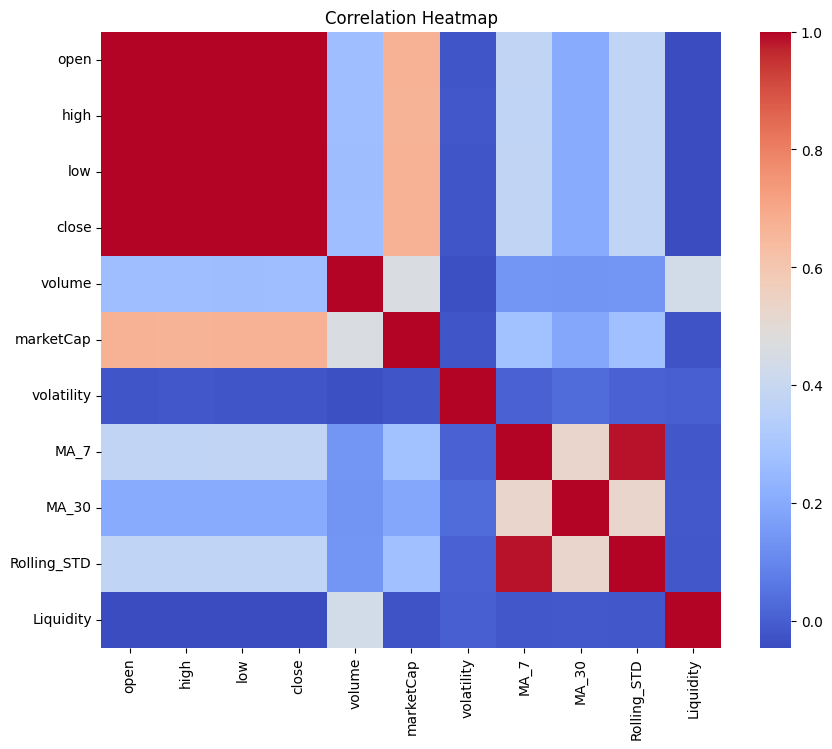

In [ ]:
# Set the figure size for better visualization
plt.figure(figsize=(10,8))
# Create a correlation heatmap to visualize the relationships between numerical features
# `numeric_only=True` ensures only numerical columns are considered for correlation
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
# Set the title of the heatmap
plt.title("Correlation Heatmap")
# Display the plot
plt.show()

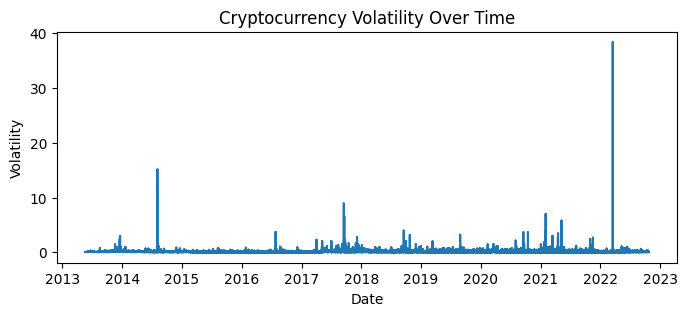

In [ ]:
# Set the figure size for the plot
plt.figure(figsize=(8,3))
# Plot the 'volatility' trend over time using 'date' on the x-axis
plt.plot(df['date'], df['volatility'])
# Set the title of the plot
plt.title("Cryptocurrency Volatility Over Time")
# Set the label for the x-axis
plt.xlabel("Date")
# Set the label for the y-axis
plt.ylabel("Volatility")
# Display the plot
plt.show()

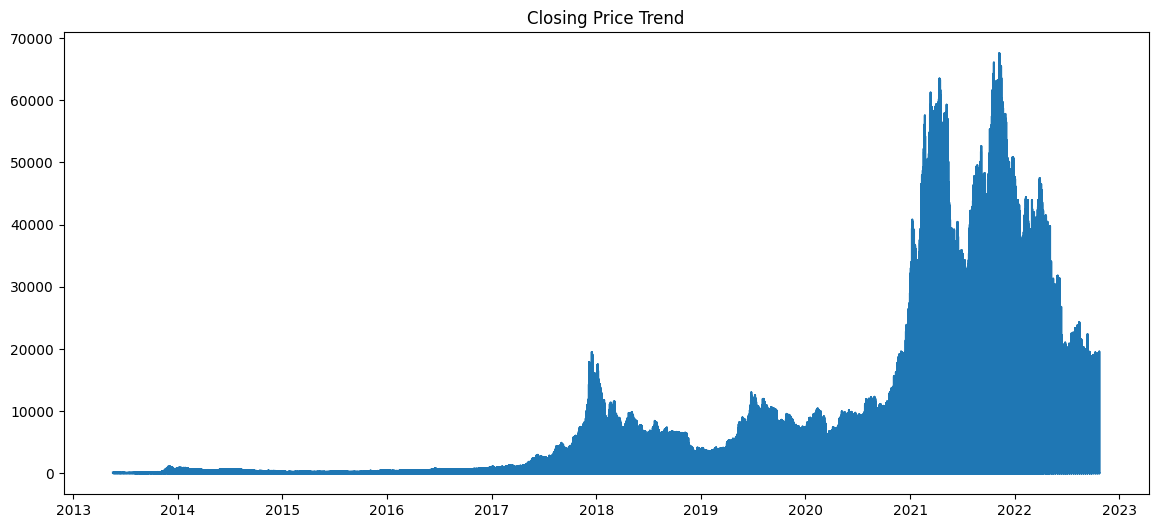

In [ ]:
# Set the figure size for the plot
plt.figure(figsize=(14,6))
# Plot the 'close' price trend over time using 'date' on the x-axis
plt.plot(df['date'], df['close'])
# Set the title of the plot
plt.title("Closing Price Trend")
# Display the plot
plt.show()

Replace any infinity values with NaN in Dataframe

In [ ]:
# Import numpy for numerical operations, specifically for handling infinity values
import numpy as np

# Re-calculate volatility with a condition to avoid division by zero
# If 'open' is 0, volatility is set to 0; otherwise, calculate (high - low) / open
df['volatility'] = np.where(
    df['open'] != 0,
    (df['high'] - df['low']) / df['open'],
    0
)

# Re-calculate 7-day Moving Average (MA_7) of the 'close' price
df['MA_7'] = df['close'].rolling(7).mean()
# Re-calculate 30-day Moving Average (MA_30) of the 'close' price
df['MA_30'] = df['close'].rolling(30).mean()

# Replace any infinity values (positive or negative) with NaN in the DataFrame
df = df.replace([np.inf, -np.inf], np.nan)

# Remove any rows that contain NaN (Not a Number) values after the calculations and replacements
df = df.dropna()

#Step 8: Select Features & Target

In [ ]:
# Define the list of features (independent variables) that will be used for training the model
features = ['open', 'high', 'low', 'close',
            'volume', 'marketCap',
            'MA_7', 'MA_30',
            'Rolling_STD', 'Liquidity']

# Create the feature matrix X using the selected features from the DataFrame
X = df[features]
# Create the target variable y (dependent variable) which is 'volatility'
y = df['volatility']

#Step 9: Train-Test Split

In [ ]:
# Split the data into training and testing sets
# X: features, y: target variable
# test_size=0.2 means 20% of the data will be used for testing, 80% for training
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

#Step 10: Feature Scaling

In [ ]:
# Check for the presence of infinity values in the training features
# This helps in identifying potential issues before scaling
np.isinf(X_train).sum()

,0
open,0
high,0
low,0
close,0
volume,0
marketCap,0
MA_7,0
MA_30,0
Rolling_STD,0
Liquidity,0


In [ ]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
# This scales features to have zero mean and unit variance
X_train = scaler.fit_transform(X_train)
# Transform the testing data using the scaler fitted on the training data
# It's crucial to use the same scaler to transform the test set to avoid data leakage
X_test = scaler.transform(X_test)

#Step 11: Train Machine Learning Models

In [ ]:
# Initialize an empty dictionary to store evaluation results for different models
results = {}

Random Forest

In [ ]:
# Train Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [ ]:
#Evaluate Random Forest
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

results['Random Forest'] = [rf_mae, rf_rmse, rf_r2]

Linear Regression

In [ ]:
#Train Linear Regression
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

# Evaluate Linear Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
lr_r2 = r2_score(y_test, lr_pred)

results['Linear Regression'] = [lr_mae, lr_rmse, lr_r2]

XGBoost

In [ ]:
#Train XGBoost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

#Evaluate XGBoost
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred)

results['XGBoost'] = [xgb_mae, xgb_rmse, xgb_r2]

#Step 12: Create Comaparison Table

In [ ]:
# Create a DataFrame to compare the evaluation metrics (MAE, RMSE, R2 Score)
# for each trained model, using the 'results' dictionary.
# The .T (transpose) is used to make model names as rows and metrics as columns.
comparison_df = pd.DataFrame(
    results,
    index=['MAE', 'RMSE', 'R2 Score']
).T

# Display the comparison DataFrame
comparison_df

,MAE,RMSE,R2 Score
XGBoost,0.039261,0.144625,0.145915
Random Forest,0.030947,0.147686,0.109370
Linear Regression,0.052154,0.155922,0.007271


#Step 12: Actual vs Predicted Graph

For XGBoost:


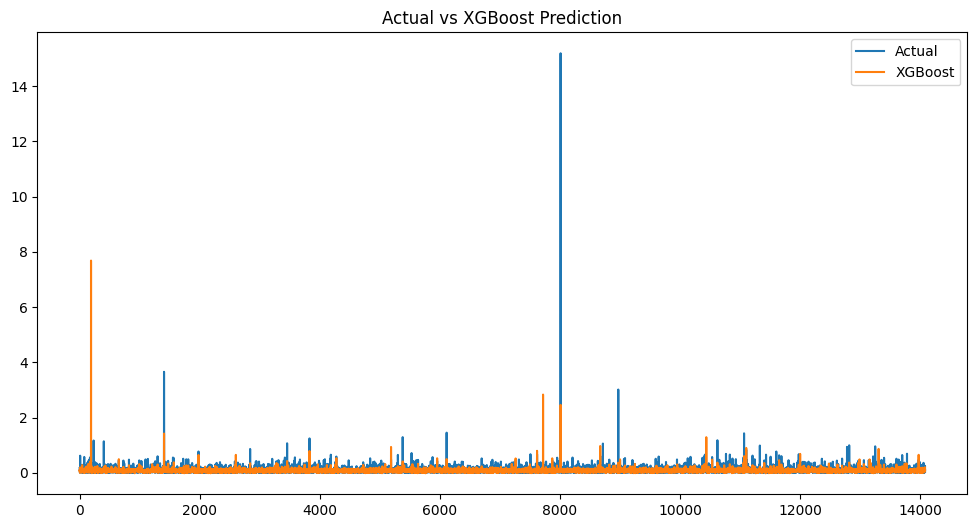

In [ ]:
# Set the figure size for the plot
plt.figure(figsize=(12,6))

# Plot the actual 'volatility' values from the test set
plt.plot(y_test.values, label='Actual')
# Plot the predicted 'volatility' values from the XGBoost model
plt.plot(xgb_pred, label='XGBoost')

# Display the legend to differentiate actual from predicted values
plt.legend()
# Set the title of the plot
plt.title("Actual vs XGBoost Prediction")

# Show the plot
plt.show()

#Step 13: Save Model

In [ ]:
# Import the joblib library for saving and loading Python objects efficiently
import joblib

# Save the trained machine learning model to a file named 'crypto_volatility_model.pkl'
# This allows the model to be reused later without retraining
joblib.dump(model, 'crypto_volatility_model.pkl')

['crypto_volatility_model.pkl']

In [ ]:
# Import the files module from google.colab to enable file download
from google.colab import files
# Download the saved model file ('crypto_volatility_model.pkl') to your local system
files.download('crypto_volatility_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>